# Analysis of the trajectories

Now that we have our trajectory we can analyze the results. For analysis there are several modules you can use. Theoretically you can write analyses yourself using the ASE atoms object or we use modules like MDAnalysis, which is what we do now. 

Link to MDAnalysis docu: https://www.mdanalysis.org/

In [6]:
from ase.io import read, write
from ase.io.trajectory import Trajectory
import itertools
import os

As stated before, trajectories in the .traj format are practical but cannot be used in MDAnalysis. Therefore, we save it to an xyz format.

In [5]:
atoms = read("traj/03_equilibration.traj", index = "-1")
mof = read("02_uio-66.cif")
try:
    frames = Trajectory("traj/04_nvt.traj")
    images = [frames[i] for i in range(len(frames))]
    write("traj/04_nvt.xyz", images)
except:
    print("Trajectory not found!")

Trajectory not found!


We want to get a radial distribution function of our MOF with our Adsorbate to see where the molecules get adsorbed. We can use the InterRDF from MDAnalysis:

https://docs.mdanalysis.org/stable/documentation_pages/analysis/rdf.html

In [3]:
import MDAnalysis as mda
from MDAnalysis.analysis.rdf import InterRDF
import numpy as np

/Users/marionsappl/miniforge3/envs/ml/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


We want to make sure that our output directories exist

In [7]:
os.makedirs("results", exist_ok=True)

In [ ]:
try:
    u = mda.Universe("traj/04_nvt.xyz")
except:
    u = mda.Universe("../trajectories/")

at0 = read("traj/04_nvt.traj", index=0)
at0.get_cell()
a,b,c,alpha,beta,gamma = at0.cell.cellpar()
u.dimensions = np.array([a,b,c,alpha,beta,gamma], dtype=float)  # applies to all frames

sel = {}

residues = ["mof","co2"]
n_atoms_mof = len(mof) - 1

atoms = {}
atoms["co2"]= ["C", "O"]
atoms["mof"] =["C","H","O","Zr"]

sel = {}
for residue in residues:
    sel[residue]={}
    for atom in atoms[residue]:
        if residue == "mof":
            sel[residue][atom] = u.select_atoms(f"name {atom} and (index 0:{n_atoms_mof})")
        else:
            sel[residue][atom] = u.select_atoms(f"name {atom} and not (index 0:{n_atoms_mof})")

combs = list(itertools.product(atoms["mof"], atoms["co2"]))

rdf = {}

for a1,a2 in combs:
    rdf[a1+a2] = InterRDF(sel["mof"][a1], sel["co2"][a2], range=(0.0, 8.0), nbins=400)
    rdf[a1+a2].run()
    data = np.column_stack([rdf[a1+a2].results.bins, rdf[a1+a2].results.rdf])
    np.savetxt(f"results/rdf_{a1}_{a2}.dat", data)

/Users/marionsappl/miniforge3/envs/ml/lib/python3.14/site-packages/MDAnalysis/analysis/base.py:562: UserWarning: Reader has no dt information, set to 1.0 ps
  self.times[idx] = ts.time


In [6]:
import matplotlib.pyplot as plt

In [7]:
colors = ["blue","orange","green","purple"]

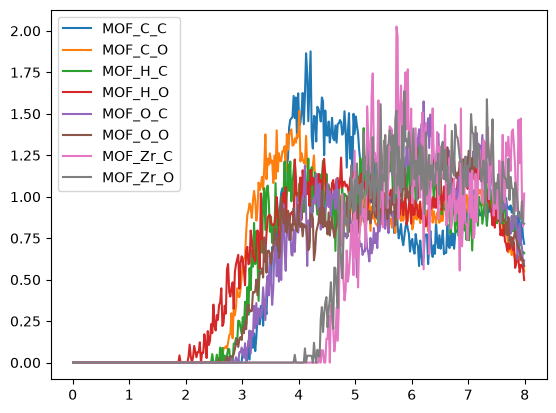

In [8]:
for a1,a2 in combs:
    plt.plot(rdf[a1+a2].results.bins, rdf[a1+a2].results.rdf, label=f"MOF_{a1}_{a2}")

plt.legend()

plt.savefig("results/rdf_all.pdf", bbox_inches="tight",dpi=300)

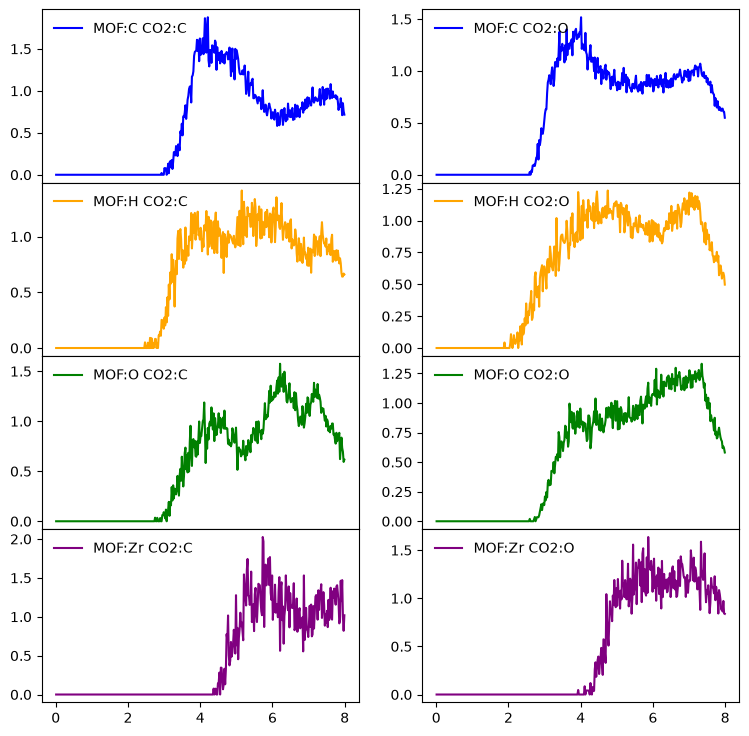

In [9]:
fig, axs = plt.subplots(len(atoms["mof"]),len(atoms["co2"]))
fig.set_size_inches(9,9)

for n1,a1 in enumerate(atoms["mof"]):
    for n2,a2 in enumerate(atoms["co2"]):
        axs[n1,n2].plot(rdf[a1+a2].results.bins, rdf[a1+a2].results.rdf, label=f"MOF:{a1} CO2:{a2}", color = colors[n1])
        axs[n1,n2].legend(loc = "upper left",frameon = False)

fig.subplots_adjust(hspace = 0)

fig.savefig("results/rdf_single.pdf", bbox_inches="tight",dpi=300)